In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
csv = pd.read_csv('scenario_summary.csv')
print(f"Total scenarios: {len(csv)}")
print(f"\nData shape: {csv.shape}")
print(f"\nColumns: {csv.columns.tolist()}")
csv.head()


Total scenarios: 7746

Data shape: (7746, 9)

Columns: ['layout_number', 'scenario_number', 'season_number', 'seasonal_match', 'historical_match', 'big_fire', 'small_fire', 'fast_fire', 'slow_fire']


,layout_number,scenario_number,season_number,seasonal_match,historical_match,big_fire,small_fire,fast_fire,slow_fire
0,4,225,2.0,False,False,True,False,False,True
1,4,640,2.0,False,False,True,False,False,True
2,4,591,2.0,False,False,True,False,False,True
3,4,993,2.0,False,False,True,False,False,True
4,4,732,2.0,False,False,True,False,False,True


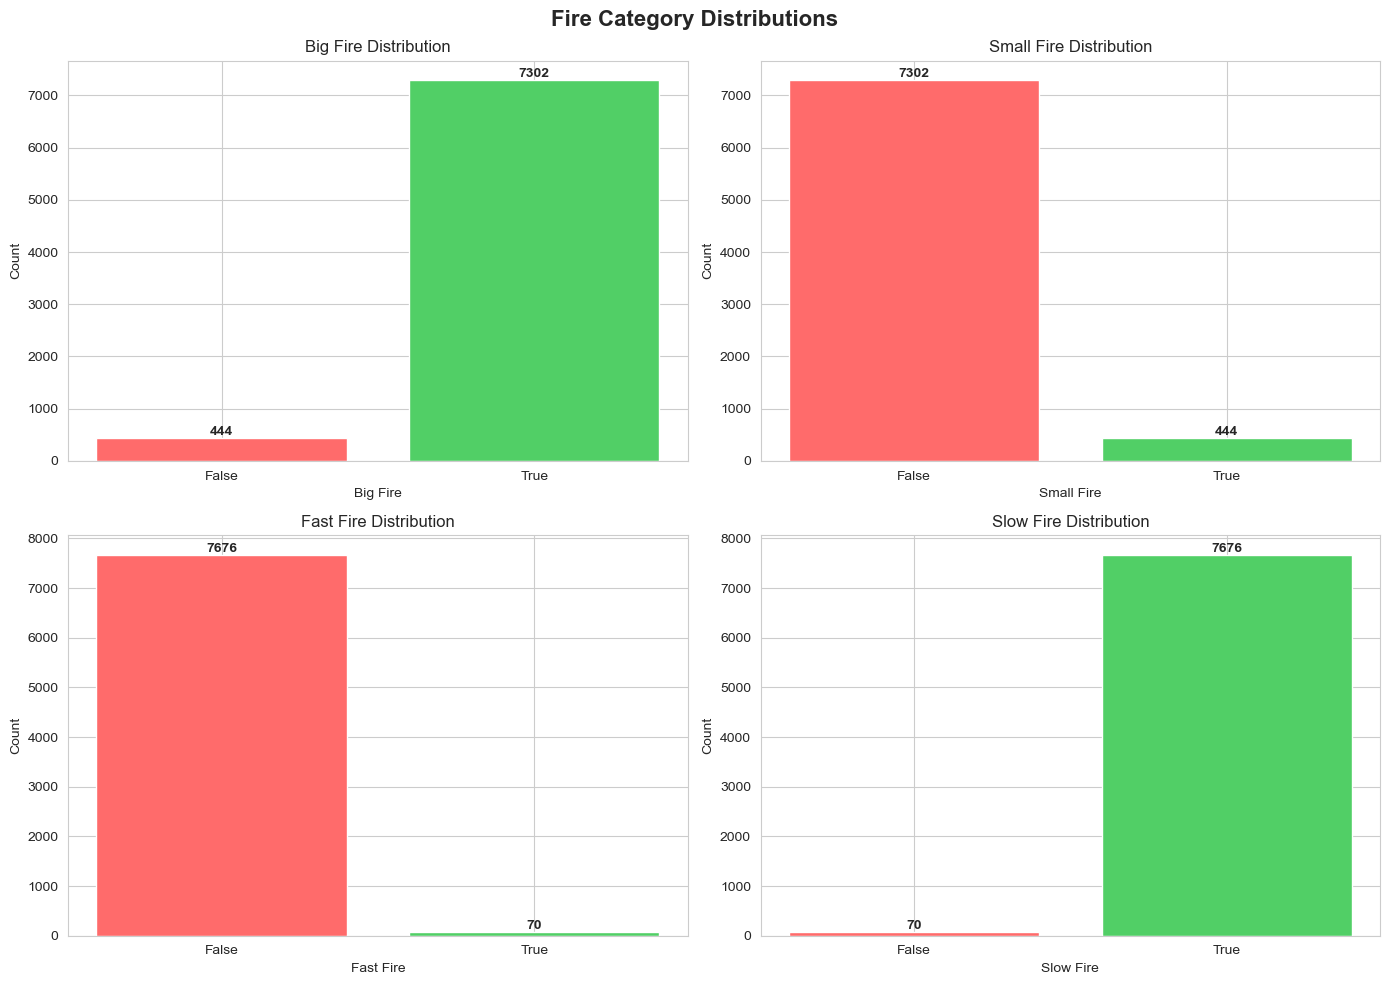


TOTAL COUNTS FOR EACH CATEGORY
Big Fire (True):   7,302
Big Fire (False):  444
Small Fire (True): 444
Small Fire (False): 7,302
Fast Fire (True):  70
Fast Fire (False): 7,676
Slow Fire (True):  7,676
Slow Fire (False): 70


In [2]:
# 1. Histograms for big_fire, small_fire, fast_fire, slow_fire
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fire Category Distributions', fontsize=16, fontweight='bold')

# Big fire
big_counts = csv['big_fire'].value_counts()
axes[0, 0].bar(['False', 'True'], [big_counts.get(False, 0), big_counts.get(True, 0)], 
               color=['#ff6b6b', '#51cf66'])
axes[0, 0].set_title('Big Fire Distribution')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlabel('Big Fire')
for i, v in enumerate([big_counts.get(False, 0), big_counts.get(True, 0)]):
    axes[0, 0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Small fire
small_counts = csv['small_fire'].value_counts()
axes[0, 1].bar(['False', 'True'], [small_counts.get(False, 0), small_counts.get(True, 0)], 
               color=['#ff6b6b', '#51cf66'])
axes[0, 1].set_title('Small Fire Distribution')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlabel('Small Fire')
for i, v in enumerate([small_counts.get(False, 0), small_counts.get(True, 0)]):
    axes[0, 1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Fast fire
fast_counts = csv['fast_fire'].value_counts()
axes[1, 0].bar(['False', 'True'], [fast_counts.get(False, 0), fast_counts.get(True, 0)], 
               color=['#ff6b6b', '#51cf66'])
axes[1, 0].set_title('Fast Fire Distribution')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlabel('Fast Fire')
for i, v in enumerate([fast_counts.get(False, 0), fast_counts.get(True, 0)]):
    axes[1, 0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Slow fire
slow_counts = csv['slow_fire'].value_counts()
axes[1, 1].bar(['False', 'True'], [slow_counts.get(False, 0), slow_counts.get(True, 0)], 
               color=['#ff6b6b', '#51cf66'])
axes[1, 1].set_title('Slow Fire Distribution')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlabel('Slow Fire')
for i, v in enumerate([slow_counts.get(False, 0), slow_counts.get(True, 0)]):
    axes[1, 1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print total counts
print("\n" + "="*50)
print("TOTAL COUNTS FOR EACH CATEGORY")
print("="*50)
print(f"Big Fire (True):   {big_counts.get(True, 0):,}")
print(f"Big Fire (False):  {big_counts.get(False, 0):,}")
print(f"Small Fire (True): {small_counts.get(True, 0):,}")
print(f"Small Fire (False): {small_counts.get(False, 0):,}")
print(f"Fast Fire (True):  {fast_counts.get(True, 0):,}")
print(f"Fast Fire (False): {fast_counts.get(False, 0):,}")
print(f"Slow Fire (True):  {slow_counts.get(True, 0):,}")
print(f"Slow Fire (False): {slow_counts.get(False, 0):,}")
print("="*50)


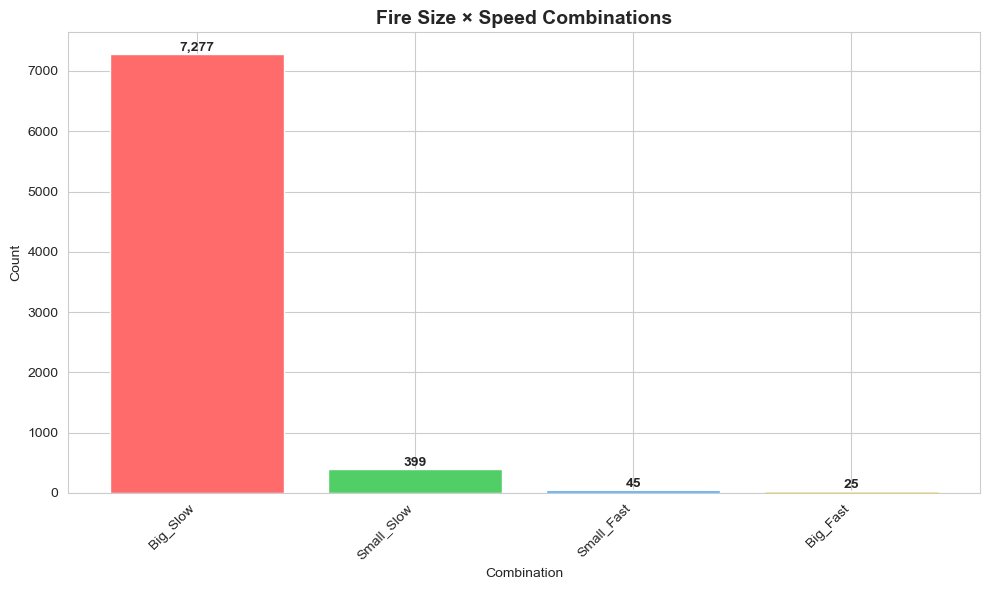


COMBINATION COUNTS: {big,small} × {fast,slow}
Big_Slow            : 7,277
Small_Slow          : 399
Small_Fast          : 45
Big_Fast            : 25


In [3]:
# 2. Combinations: {big,small} x {fast, slow}
# Create combination categories
csv['size_category'] = csv.apply(lambda x: 'Big' if x['big_fire'] else 'Small', axis=1)
csv['speed_category'] = csv.apply(lambda x: 'Fast' if x['fast_fire'] else 'Slow', axis=1)
csv['size_speed_combo'] = csv['size_category'] + '_' + csv['speed_category']

# Also create match_category for later use
csv['match_category'] = csv.apply(
    lambda x: 'Both' if (x['seasonal_match'] and x['historical_match']) 
    else 'Seasonal' if x['seasonal_match'] 
    else 'Historical' if x['historical_match'] 
    else 'None', axis=1
)

combo_counts = csv['size_speed_combo'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff6b6b', '#51cf66', '#4dabf7', '#ffd43b']
bars = ax.bar(combo_counts.index, combo_counts.values, color=colors[:len(combo_counts)])
ax.set_title('Fire Size × Speed Combinations', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Combination')
ax.set_xticks(range(len(combo_counts)))
ax.set_xticklabels(combo_counts.index, rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print counts
print("\n" + "="*50)
print("COMBINATION COUNTS: {big,small} × {fast,slow}")
print("="*50)
for combo, count in combo_counts.items():
    print(f"{combo:20s}: {count:,}")
print("="*50)


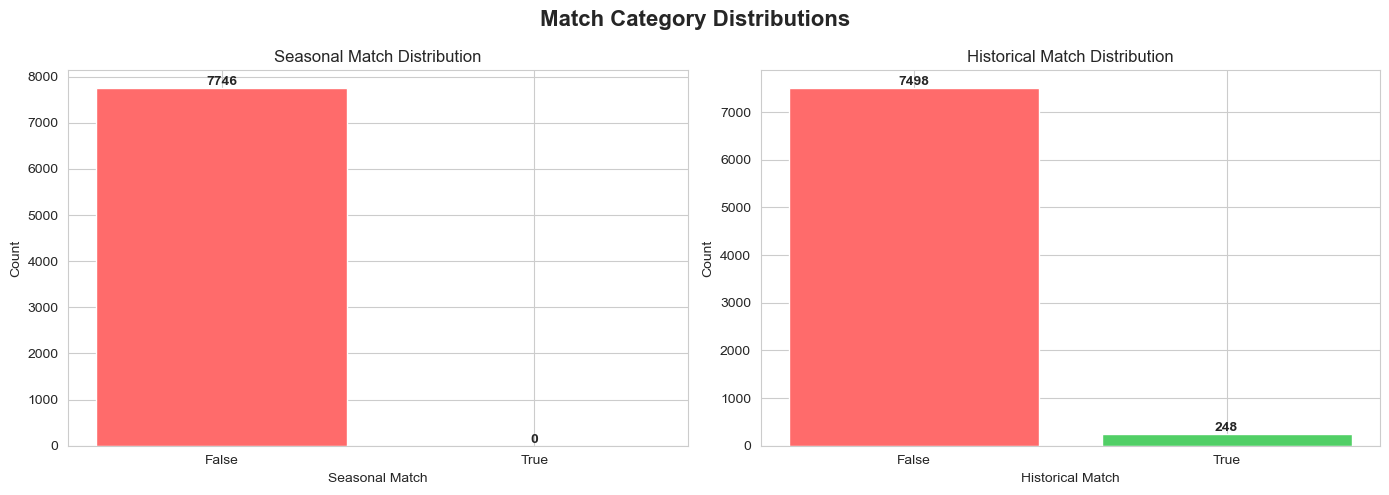


SEASONAL MATCH
seasonal_match
False    7746
Name: count, dtype: int64

Total: 7,746

HISTORICAL MATCH
historical_match
False    7498
True      248
Name: count, dtype: int64

Total: 7,746


In [4]:
# 3. Histograms/tables for seasonal_match and historical_match
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Match Category Distributions', fontsize=16, fontweight='bold')

# Seasonal match
seasonal_counts = csv['seasonal_match'].value_counts()
axes[0].bar(['False', 'True'], [seasonal_counts.get(False, 0), seasonal_counts.get(True, 0)], 
            color=['#ff6b6b', '#51cf66'])
axes[0].set_title('Seasonal Match Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Seasonal Match')
for i, v in enumerate([seasonal_counts.get(False, 0), seasonal_counts.get(True, 0)]):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Historical match
historical_counts = csv['historical_match'].value_counts()
axes[1].bar(['False', 'True'], [historical_counts.get(False, 0), historical_counts.get(True, 0)], 
            color=['#ff6b6b', '#51cf66'])
axes[1].set_title('Historical Match Distribution')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Historical Match')
for i, v in enumerate([historical_counts.get(False, 0), historical_counts.get(True, 0)]):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print tables
print("\n" + "="*50)
print("SEASONAL MATCH")
print("="*50)
print(seasonal_counts)
print(f"\nTotal: {seasonal_counts.sum():,}")

print("\n" + "="*50)
print("HISTORICAL MATCH")
print("="*50)
print(historical_counts)
print(f"\nTotal: {historical_counts.sum():,}")
print("="*50)


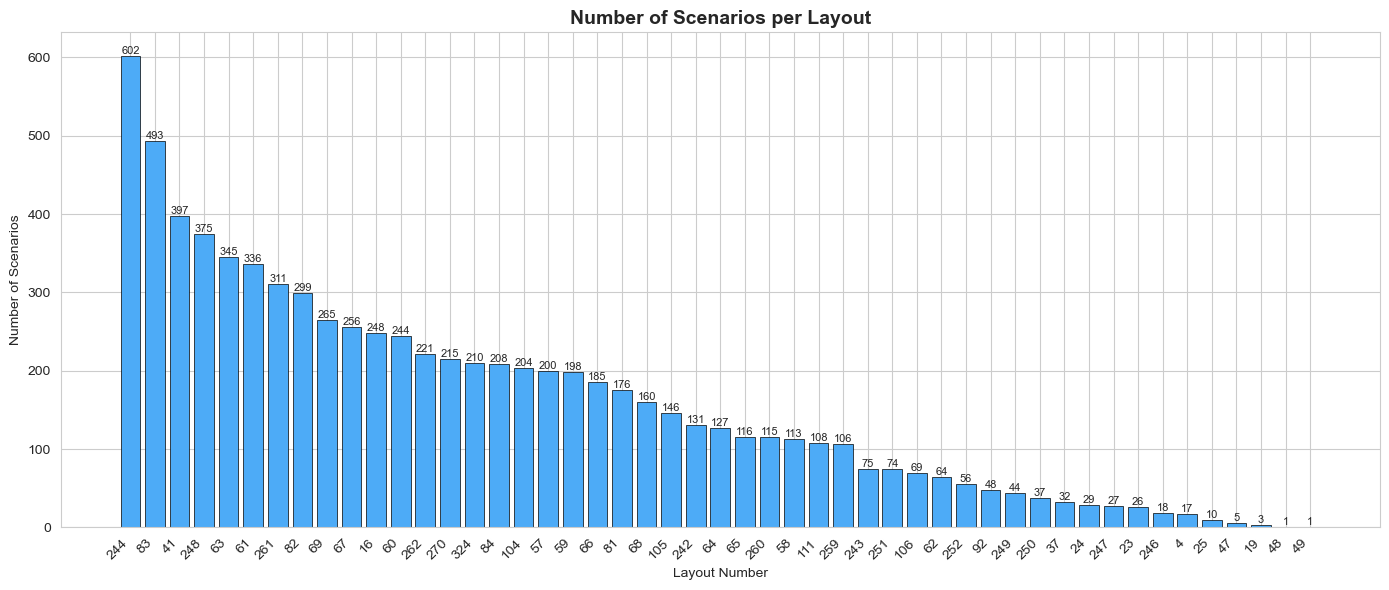


SCENARIOS PER LAYOUT - SUMMARY STATISTICS
Total layouts: 49
Total scenarios: 7,746
Mean scenarios per layout: 158.08
Median scenarios per layout: 127.00
Min scenarios per layout: 1
Max scenarios per layout: 602

Top 10 layouts by scenario count:
layout_number
244    602
83     493
41     397
248    375
63     345
61     336
261    311
82     299
69     265
67     256
dtype: int64


In [9]:
# 4. Histogram of scenarios per layout
scenarios_per_layout = csv.groupby('layout_number').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(scenarios_per_layout)), scenarios_per_layout.values, 
              color='#4dabf7', edgecolor='black', linewidth=0.5)
ax.set_title('Number of Scenarios per Layout', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Scenarios')
ax.set_xlabel('Layout Number')
ax.set_xticks(range(len(scenarios_per_layout)))
ax.set_xticklabels(scenarios_per_layout.index, rotation=45, ha='right')

# Add value labels on top of bars (only for top 10 to avoid clutter)
for i, (idx, val) in enumerate(scenarios_per_layout.items()):
    ax.text(i, val, str(int(val)), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("SCENARIOS PER LAYOUT - SUMMARY STATISTICS")
print("="*50)
print(f"Total layouts: {len(scenarios_per_layout)}")
print(f"Total scenarios: {scenarios_per_layout.sum():,}")
print(f"Mean scenarios per layout: {scenarios_per_layout.mean():.2f}")
print(f"Median scenarios per layout: {scenarios_per_layout.median():.2f}")
print(f"Min scenarios per layout: {scenarios_per_layout.min()}")
print(f"Max scenarios per layout: {scenarios_per_layout.max()}")
print(f"\nTop 10 layouts by scenario count:")
print(scenarios_per_layout.head(10))
print("="*50)


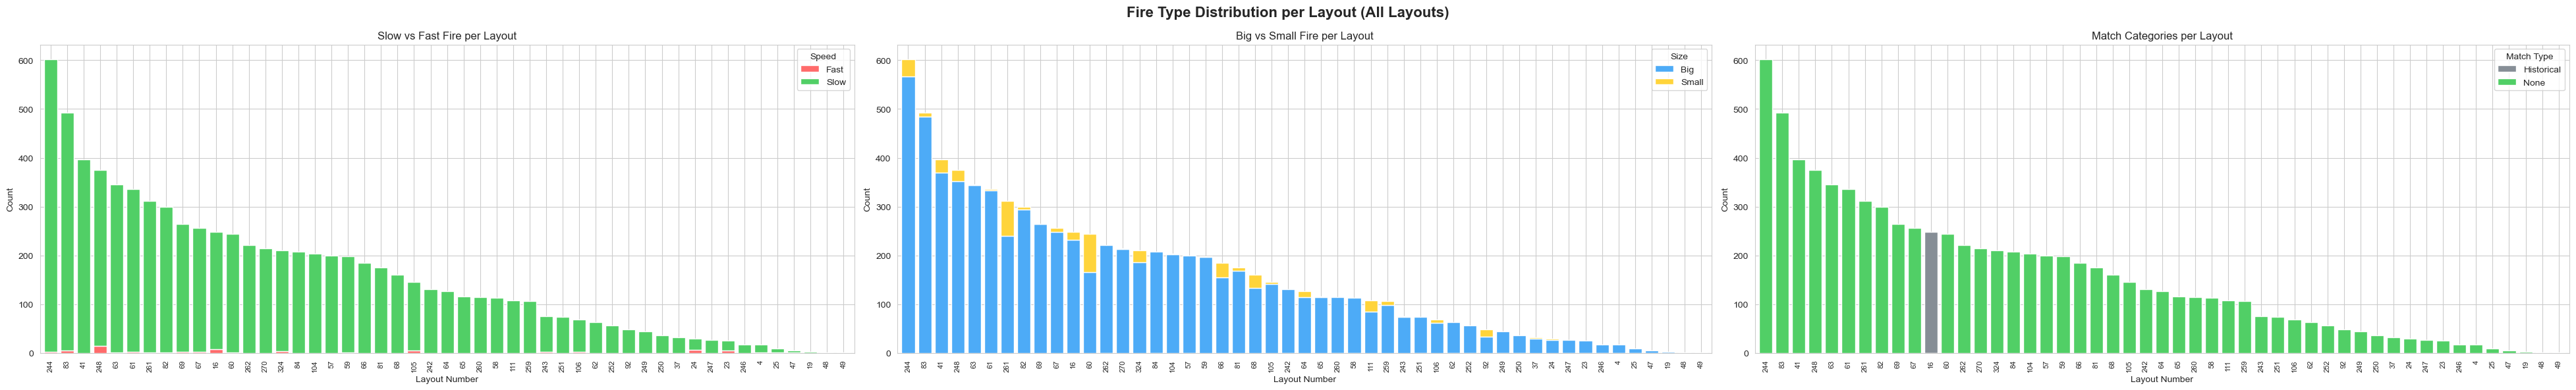

In [6]:
# 5. Stacked bar charts: Fire types per layout
# Convert layout_number to string for consistency
csv['layout_number'] = csv['layout_number'].astype(str)

# Get all layouts sorted by scenario count
all_layouts = csv.groupby('layout_number').size().sort_values(ascending=False).index.tolist()
num_layouts = len(all_layouts)

# 5a. Slow/Fast per layout
fig, axes = plt.subplots(1, 3, figsize=(max(30, num_layouts * 0.8), 6))
fig.suptitle('Fire Type Distribution per Layout (All Layouts)', fontsize=16, fontweight='bold')

# Slow/Fast
slow_fast_per_layout = csv.groupby(['layout_number', 'speed_category']).size().unstack(fill_value=0)
slow_fast_per_layout = slow_fast_per_layout.reindex(all_layouts)
slow_fast_per_layout.plot(kind='bar', stacked=True, ax=axes[0], 
                          color=['#ff6b6b', '#51cf66'], width=0.8)
axes[0].set_title('Slow vs Fast Fire per Layout')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Layout Number')
axes[0].legend(title='Speed')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)

# Big/Small per layout
big_small_per_layout = csv.groupby(['layout_number', 'size_category']).size().unstack(fill_value=0)
big_small_per_layout = big_small_per_layout.reindex(all_layouts)
big_small_per_layout.plot(kind='bar', stacked=True, ax=axes[1], 
                          color=['#4dabf7', '#ffd43b'], width=0.8)
axes[1].set_title('Big vs Small Fire per Layout')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Layout Number')
axes[1].legend(title='Size')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)

# Match categories per layout (match_category already created in cell 3)
match_per_layout = csv.groupby(['layout_number', 'match_category']).size().unstack(fill_value=0)
match_per_layout = match_per_layout.reindex(all_layouts)
match_per_layout.plot(kind='bar', stacked=True, ax=axes[2], 
                      color=['#868e96', '#51cf66', '#4dabf7', '#ffd43b'], width=0.8)
axes[2].set_title('Match Categories per Layout')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Layout Number')
axes[2].legend(title='Match Type')
axes[2].tick_params(axis='x', rotation=90, labelsize=8)

plt.tight_layout()
plt.show()


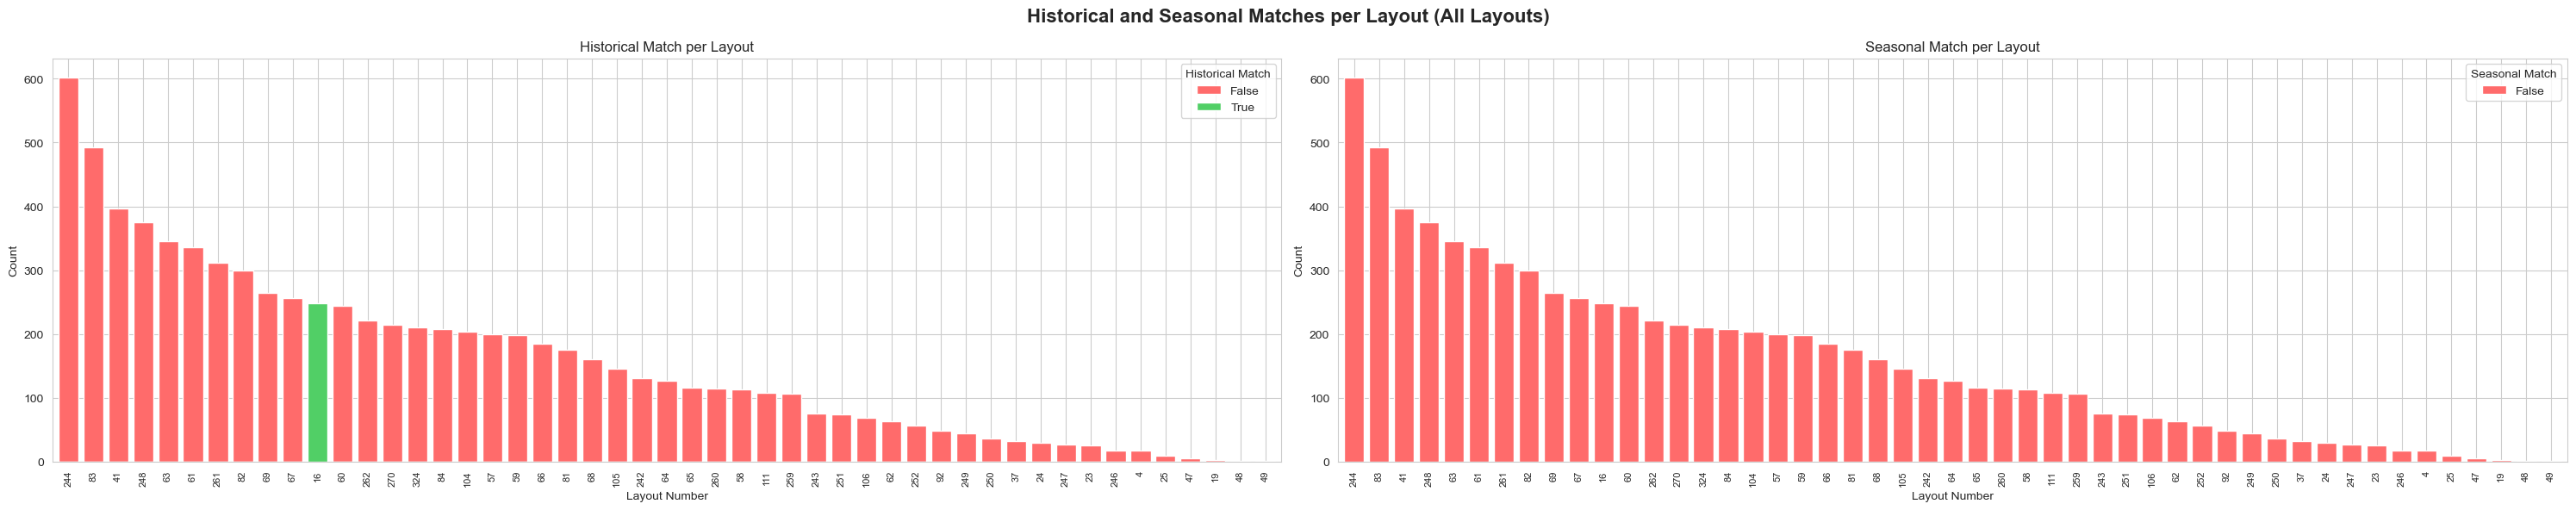


HISTORICAL MATCH PER LAYOUT - SUMMARY
Total layouts: 49

Historical match counts (True/False) for top 5 layouts:
Layout 244: True=0, False=602
Layout 83: True=0, False=493
Layout 41: True=0, False=397
Layout 248: True=0, False=375
Layout 63: True=0, False=345

SEASONAL MATCH PER LAYOUT - SUMMARY
Total layouts: 49

Seasonal match counts (True/False) for top 5 layouts:
Layout 244: True=0, False=602
Layout 83: True=0, False=493
Layout 41: True=0, False=397
Layout 248: True=0, False=375
Layout 63: True=0, False=345


In [7]:
# Additional: Historical and Seasonal matches per layout (stacked bars)
# Convert layout_number to string for consistency
csv['layout_number'] = csv['layout_number'].astype(str)

# Get all layouts sorted by scenario count
all_layouts = csv.groupby('layout_number').size().sort_values(ascending=False).index.tolist()
num_layouts = len(all_layouts)

fig, axes = plt.subplots(1, 2, figsize=(max(30, num_layouts * 0.6), 6))
fig.suptitle('Historical and Seasonal Matches per Layout (All Layouts)', fontsize=16, fontweight='bold')

# Historical match per layout
historical_per_layout = csv.groupby(['layout_number', 'historical_match']).size().unstack(fill_value=0)
historical_per_layout = historical_per_layout.reindex(all_layouts)
historical_per_layout.plot(kind='bar', stacked=True, ax=axes[0], 
                          color=['#ff6b6b', '#51cf66'], width=0.8)
axes[0].set_title('Historical Match per Layout')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Layout Number')
axes[0].legend(title='Historical Match', labels=['False', 'True'])
axes[0].tick_params(axis='x', rotation=90, labelsize=8)

# Seasonal match per layout
seasonal_per_layout = csv.groupby(['layout_number', 'seasonal_match']).size().unstack(fill_value=0)
seasonal_per_layout = seasonal_per_layout.reindex(all_layouts)
seasonal_per_layout.plot(kind='bar', stacked=True, ax=axes[1], 
                         color=['#ff6b6b', '#51cf66'], width=0.8)
axes[1].set_title('Seasonal Match per Layout')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Layout Number')
axes[1].legend(title='Seasonal Match', labels=['False', 'True'])
axes[1].tick_params(axis='x', rotation=90, labelsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("HISTORICAL MATCH PER LAYOUT - SUMMARY")
print("="*50)
print(f"Total layouts: {len(all_layouts)}")
print(f"\nHistorical match counts (True/False) for top 5 layouts:")
for layout in all_layouts[:5]:
    true_count = historical_per_layout.loc[layout, True] if True in historical_per_layout.columns else 0
    false_count = historical_per_layout.loc[layout, False] if False in historical_per_layout.columns else 0
    print(f"Layout {layout}: True={int(true_count)}, False={int(false_count)}")

print("\n" + "="*50)
print("SEASONAL MATCH PER LAYOUT - SUMMARY")
print("="*50)
print(f"Total layouts: {len(all_layouts)}")
print(f"\nSeasonal match counts (True/False) for top 5 layouts:")
for layout in all_layouts[:5]:
    true_count = seasonal_per_layout.loc[layout, True] if True in seasonal_per_layout.columns else 0
    false_count = seasonal_per_layout.loc[layout, False] if False in seasonal_per_layout.columns else 0
    print(f"Layout {layout}: True={int(true_count)}, False={int(false_count)}")
print("="*50)


In [ ]:
# Table: Seasonal and Historical match counts per layout
# Convert layout_number to string for consistency
csv['layout_number'] = csv['layout_number'].astype(str)

# Create summary table using groupby for efficiency
historical_counts = csv.groupby(['layout_number', 'historical_match']).size().unstack(fill_value=0)
seasonal_counts = csv.groupby(['layout_number', 'seasonal_match']).size().unstack(fill_value=0)
total_counts = csv.groupby('layout_number').size()

# Get all layouts sorted by total scenarios
all_layouts = total_counts.sort_values(ascending=False).index

# Build the table by combining the dataframes
match_table = pd.DataFrame(index=all_layouts)
match_table['Layout'] = all_layouts
match_table['Total_Scenarios'] = total_counts.reindex(all_layouts)

# Add historical match columns
if True in historical_counts.columns:
    match_table['Historical_Match_True'] = historical_counts.reindex(all_layouts)[True].fillna(0)
else:
    match_table['Historical_Match_True'] = 0

if False in historical_counts.columns:
    match_table['Historical_Match_False'] = historical_counts.reindex(all_layouts)[False].fillna(0)
else:
    match_table['Historical_Match_False'] = 0

# Add seasonal match columns
if True in seasonal_counts.columns:
    match_table['Seasonal_Match_True'] = seasonal_counts.reindex(all_layouts)[True].fillna(0)
else:
    match_table['Seasonal_Match_True'] = 0

if False in seasonal_counts.columns:
    match_table['Seasonal_Match_False'] = seasonal_counts.reindex(all_layouts)[False].fillna(0)
else:
    match_table['Seasonal_Match_False'] = 0

# Calculate percentages
match_table['Historical_Match_True_%'] = (match_table['Historical_Match_True'] / match_table['Total_Scenarios'] * 100).round(2)
match_table['Seasonal_Match_True_%'] = (match_table['Seasonal_Match_True'] / match_table['Total_Scenarios'] * 100).round(2)

# Reset index and convert to integers where appropriate
match_table = match_table.reset_index(drop=True)
match_table['Historical_Match_True'] = match_table['Historical_Match_True'].astype(int)
match_table['Historical_Match_False'] = match_table['Historical_Match_False'].astype(int)
match_table['Seasonal_Match_True'] = match_table['Seasonal_Match_True'].astype(int)
match_table['Seasonal_Match_False'] = match_table['Seasonal_Match_False'].astype(int)

# Display the table
print("\n" + "="*100)
print("SEASONAL AND HISTORICAL MATCH COUNTS PER LAYOUT")
print("="*100)
print(match_table.to_string(index=False))
print("="*100)

# Also display as a nicely formatted table with styling
display(match_table.style.format({
    'Historical_Match_True_%': '{:.2f}%',
    'Seasonal_Match_True_%': '{:.2f}%'
}).background_gradient(subset=['Historical_Match_True', 'Seasonal_Match_True'], cmap='YlOrRd'))



SEASONAL AND HISTORICAL MATCH COUNTS PER LAYOUT
Layout  Total_Scenarios  Historical_Match_True  Historical_Match_False  Seasonal_Match_True  Seasonal_Match_False  Historical_Match_True_%  Seasonal_Match_True_%
   244              602                      0                     602                    0                   602                      0.0                    0.0
    83              493                      0                     493                    0                   493                      0.0                    0.0
    41              397                      0                     397                    0                   397                      0.0                    0.0
   248              375                      0                     375                    0                   375                      0.0                    0.0
    63              345                      0                     345                    0                   345                      0.0   

AttributeError: The '.style' accessor requires jinja2

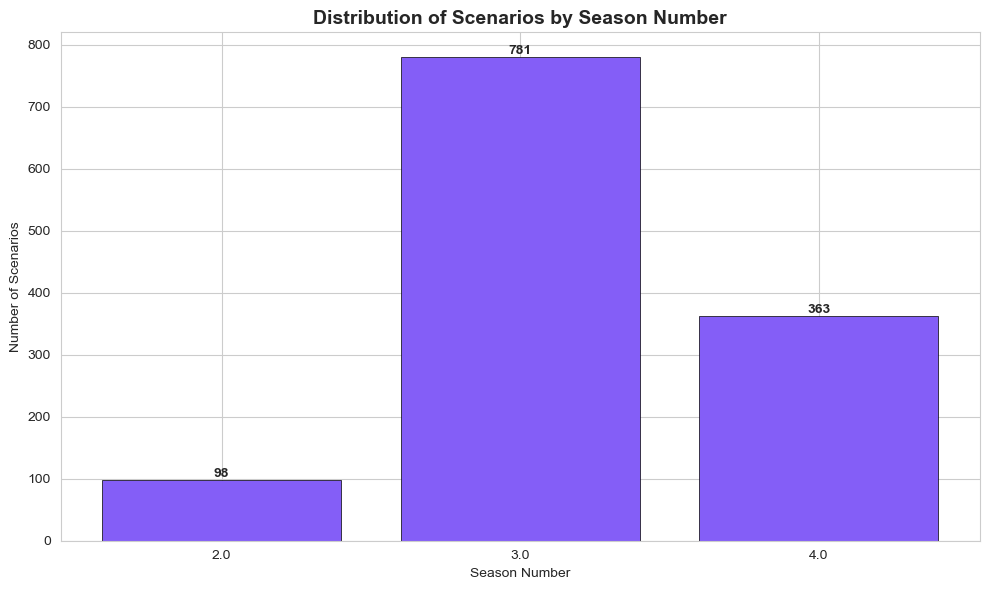


SEASON NUMBER DISTRIBUTION
season_number
2.0     98
3.0    781
4.0    363
Name: count, dtype: int64

Total: 1,242
NaN count: 6,504


In [ ]:
# ADDITIONAL VISUALIZATIONS

# 6. Season number distribution
fig, ax = plt.subplots(figsize=(10, 6))
season_counts = csv['season_number'].value_counts().sort_index()
bars = ax.bar(season_counts.index.astype(str), season_counts.values, 
              color='#845ef7', edgecolor='black', linewidth=0.5)
ax.set_title('Distribution of Scenarios by Season Number', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Scenarios')
ax.set_xlabel('Season Number')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("SEASON NUMBER DISTRIBUTION")
print("="*50)
print(season_counts)
print(f"\nTotal: {season_counts.sum():,}")
print(f"NaN count: {csv['season_number'].isna().sum():,}")
print("="*50)


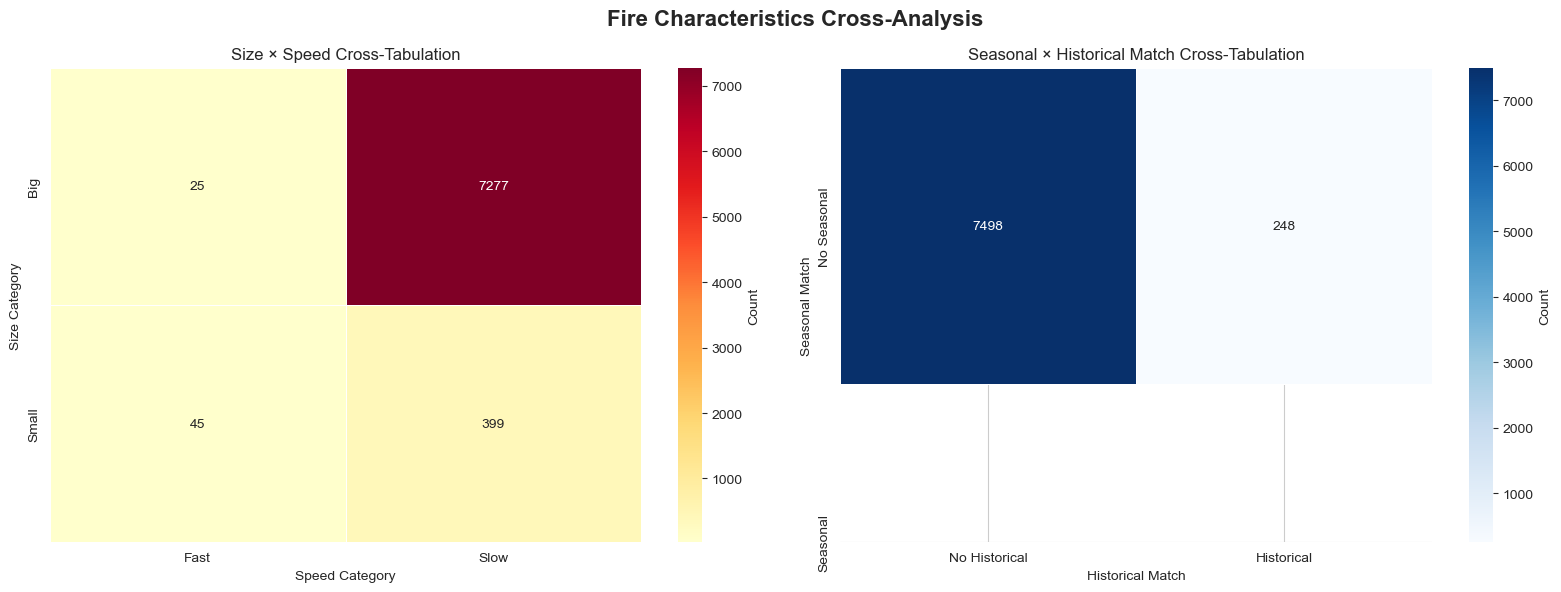


SIZE × SPEED CROSS-TABULATION
speed_category  Fast  Slow
size_category             
Big               25  7277
Small             45   399

SEASONAL × HISTORICAL MATCH CROSS-TABULATION
historical_match  False  True 
seasonal_match                
False              7498    248


In [43]:
# 7. Cross-tabulation: Size × Speed with Match information
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Fire Characteristics Cross-Analysis', fontsize=16, fontweight='bold')

# Size × Speed heatmap
size_speed_crosstab = pd.crosstab(csv['size_category'], csv['speed_category'])
sns.heatmap(size_speed_crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], 
            cbar_kws={'label': 'Count'}, linewidths=0.5)
axes[0].set_title('Size × Speed Cross-Tabulation')
axes[0].set_xlabel('Speed Category')
axes[0].set_ylabel('Size Category')

# Match combinations
match_combo = pd.crosstab(csv['seasonal_match'], csv['historical_match'])
sns.heatmap(match_combo, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            cbar_kws={'label': 'Count'}, linewidths=0.5, 
            xticklabels=['No Historical', 'Historical'], 
            yticklabels=['No Seasonal', 'Seasonal'])
axes[1].set_title('Seasonal × Historical Match Cross-Tabulation')
axes[1].set_xlabel('Historical Match')
axes[1].set_ylabel('Seasonal Match')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("SIZE × SPEED CROSS-TABULATION")
print("="*50)
print(size_speed_crosstab)
print("\n" + "="*50)
print("SEASONAL × HISTORICAL MATCH CROSS-TABULATION")
print("="*50)
print(match_combo)
print("="*50)


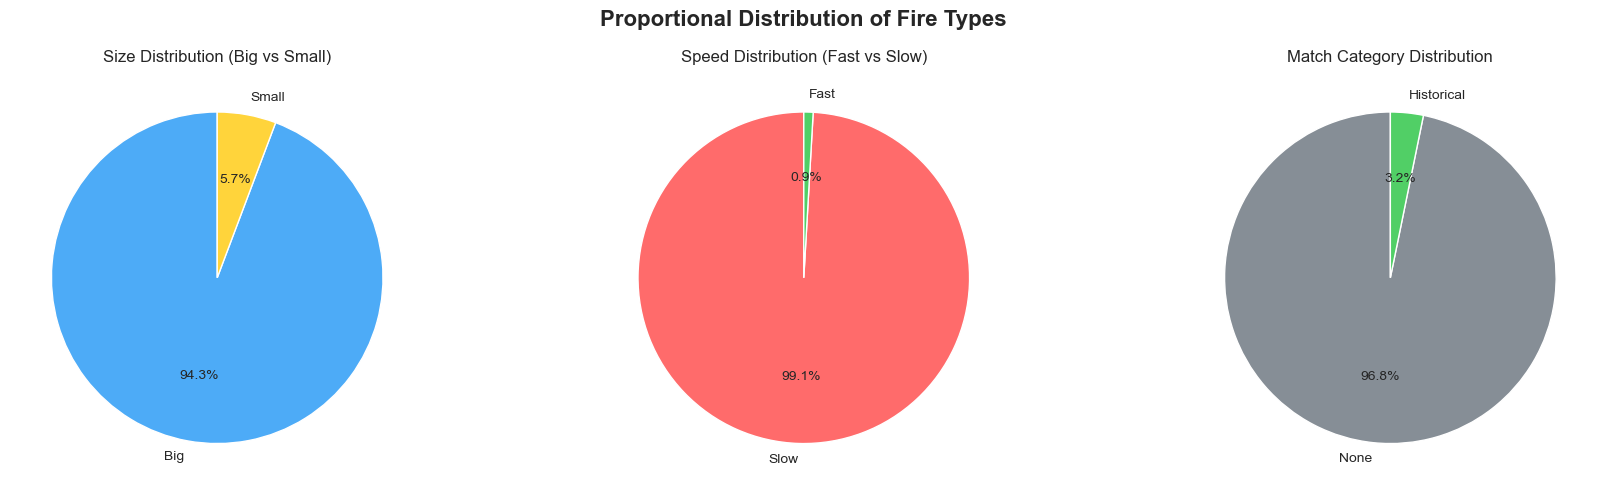


PROPORTIONAL DISTRIBUTIONS

Size Distribution:
size_category
Big      94.268009
Small     5.731991
Name: proportion, dtype: float64

Speed Distribution:
speed_category
Slow    99.096308
Fast     0.903692
Name: proportion, dtype: float64

Match Category Distribution:
match_category
None          96.798348
Historical     3.201652
Name: proportion, dtype: float64


In [44]:
# 8. Distribution of fire types across all layouts (proportion view)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Proportional Distribution of Fire Types', fontsize=16, fontweight='bold')

# Size distribution
size_props = csv['size_category'].value_counts(normalize=True) * 100
axes[0].pie(size_props.values, labels=size_props.index, autopct='%1.1f%%', 
            colors=['#4dabf7', '#ffd43b'], startangle=90)
axes[0].set_title('Size Distribution (Big vs Small)')

# Speed distribution
speed_props = csv['speed_category'].value_counts(normalize=True) * 100
axes[1].pie(speed_props.values, labels=speed_props.index, autopct='%1.1f%%', 
            colors=['#ff6b6b', '#51cf66'], startangle=90)
axes[1].set_title('Speed Distribution (Fast vs Slow)')

# Match distribution
match_props = csv['match_category'].value_counts(normalize=True) * 100
axes[2].pie(match_props.values, labels=match_props.index, autopct='%1.1f%%', 
            colors=['#868e96', '#51cf66', '#4dabf7', '#ffd43b'], startangle=90)
axes[2].set_title('Match Category Distribution')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("PROPORTIONAL DISTRIBUTIONS")
print("="*50)
print("\nSize Distribution:")
print(size_props)
print("\nSpeed Distribution:")
print(speed_props)
print("\nMatch Category Distribution:")
print(match_props)
print("="*50)


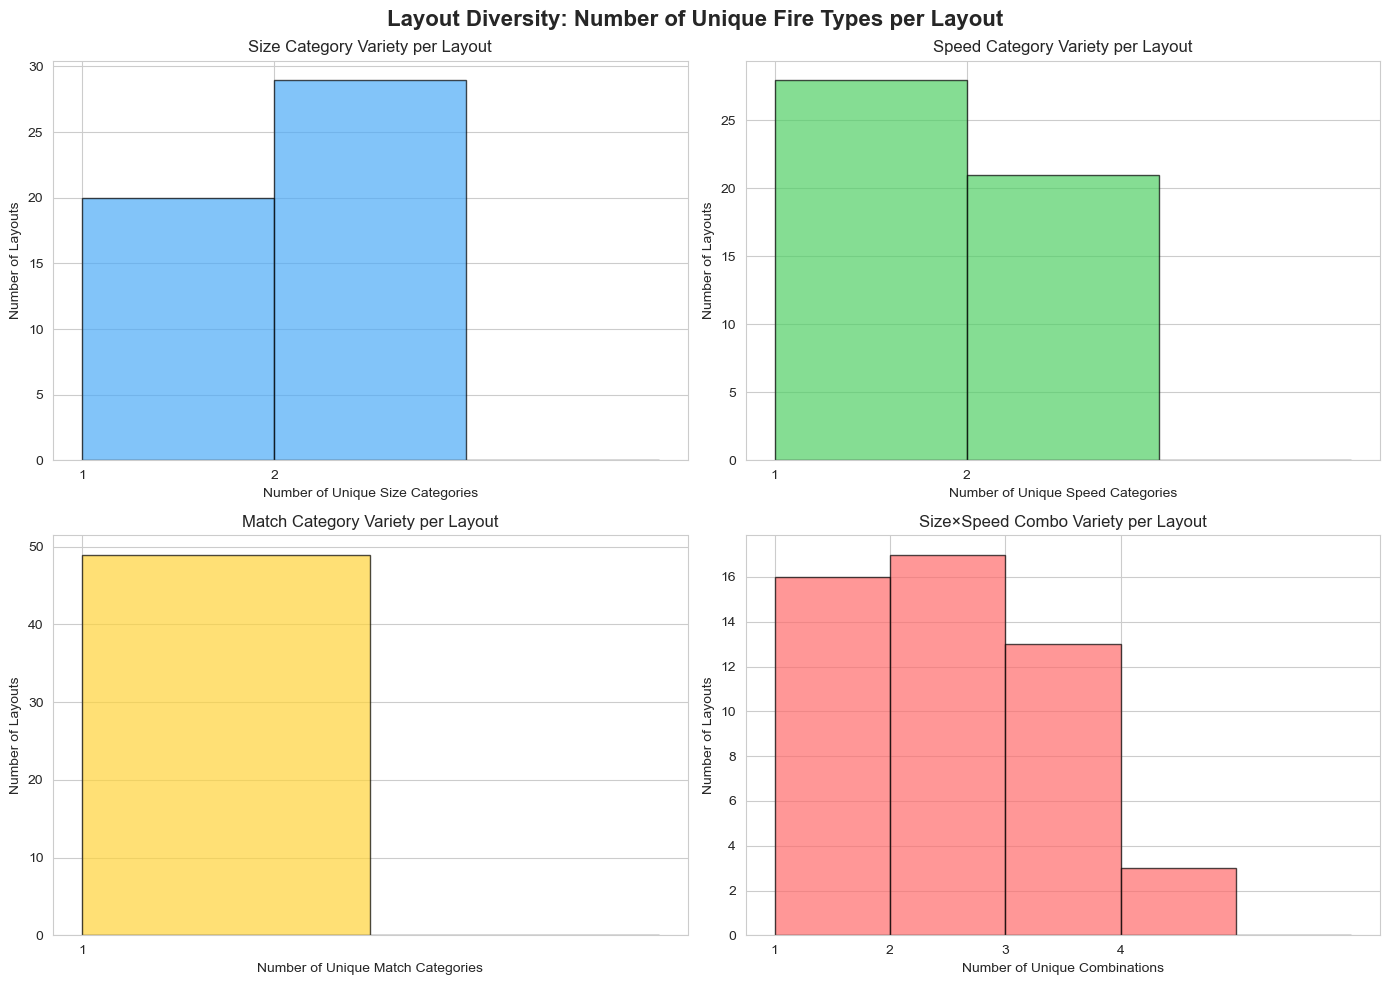


LAYOUT DIVERSITY SUMMARY
       size_variety  speed_variety  match_variety  combo_variety
count     49.000000      49.000000           49.0      49.000000
mean       1.591837       1.428571            1.0       2.061224
std        0.496587       0.500000            0.0       0.922139
min        1.000000       1.000000            1.0       1.000000
25%        1.000000       1.000000            1.0       1.000000
50%        2.000000       1.000000            1.0       2.000000
75%        2.000000       2.000000            1.0       3.000000
max        2.000000       2.000000            1.0       4.000000


In [45]:
# 9. Layout diversity: How many different fire types per layout
layout_diversity = csv.groupby('layout_number').agg({
    'size_category': lambda x: x.nunique(),
    'speed_category': lambda x: x.nunique(),
    'match_category': lambda x: x.nunique(),
    'size_speed_combo': lambda x: x.nunique()
}).rename(columns={
    'size_category': 'size_variety',
    'speed_category': 'speed_variety',
    'match_category': 'match_variety',
    'size_speed_combo': 'combo_variety'
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Layout Diversity: Number of Unique Fire Types per Layout', fontsize=16, fontweight='bold')

# Size variety
axes[0, 0].hist(layout_diversity['size_variety'], bins=range(1, layout_diversity['size_variety'].max()+3), 
                color='#4dabf7', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Size Category Variety per Layout')
axes[0, 0].set_xlabel('Number of Unique Size Categories')
axes[0, 0].set_ylabel('Number of Layouts')
axes[0, 0].set_xticks(range(1, layout_diversity['size_variety'].max()+1))

# Speed variety
axes[0, 1].hist(layout_diversity['speed_variety'], bins=range(1, layout_diversity['speed_variety'].max()+3), 
                color='#51cf66', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Speed Category Variety per Layout')
axes[0, 1].set_xlabel('Number of Unique Speed Categories')
axes[0, 1].set_ylabel('Number of Layouts')
axes[0, 1].set_xticks(range(1, layout_diversity['speed_variety'].max()+1))

# Match variety
axes[1, 0].hist(layout_diversity['match_variety'], bins=range(1, layout_diversity['match_variety'].max()+3), 
                color='#ffd43b', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Match Category Variety per Layout')
axes[1, 0].set_xlabel('Number of Unique Match Categories')
axes[1, 0].set_ylabel('Number of Layouts')
axes[1, 0].set_xticks(range(1, layout_diversity['match_variety'].max()+1))

# Combo variety
axes[1, 1].hist(layout_diversity['combo_variety'], bins=range(1, layout_diversity['combo_variety'].max()+3), 
                color='#ff6b6b', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Size×Speed Combo Variety per Layout')
axes[1, 1].set_xlabel('Number of Unique Combinations')
axes[1, 1].set_ylabel('Number of Layouts')
axes[1, 1].set_xticks(range(1, min(layout_diversity['combo_variety'].max()+1, 5)))

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("LAYOUT DIVERSITY SUMMARY")
print("="*50)
print(layout_diversity.describe())
print("="*50)


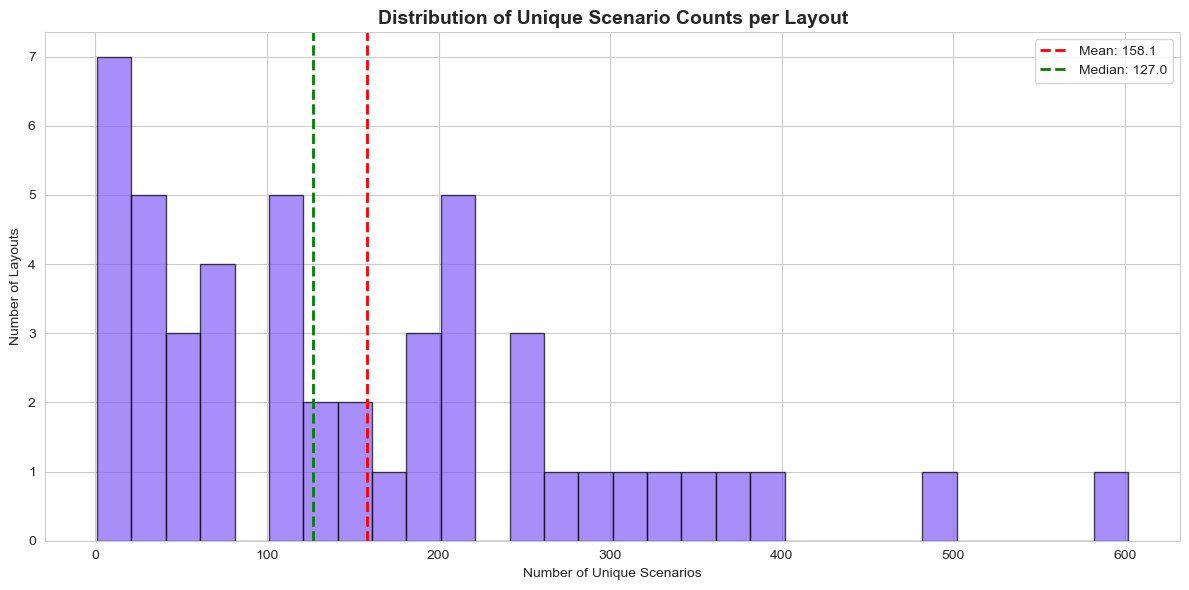


UNIQUE SCENARIOS PER LAYOUT - STATISTICS
Mean unique scenarios per layout: 158.08
Median unique scenarios per layout: 127.00
Min unique scenarios per layout: 1
Max unique scenarios per layout: 602
Std dev: 136.76


In [46]:
# 10. Scenario number distribution per layout
fig, ax = plt.subplots(figsize=(12, 6))

# Get scenario counts per layout
scenario_counts = csv.groupby('layout_number')['scenario_number'].nunique().sort_values(ascending=False)

# Create histogram
ax.hist(scenario_counts.values, bins=30, color='#845ef7', edgecolor='black', alpha=0.7)
ax.set_title('Distribution of Unique Scenario Counts per Layout', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Unique Scenarios')
ax.set_ylabel('Number of Layouts')
ax.axvline(scenario_counts.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {scenario_counts.mean():.1f}')
ax.axvline(scenario_counts.median(), color='green', linestyle='--', linewidth=2, 
           label=f'Median: {scenario_counts.median():.1f}')
ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("UNIQUE SCENARIOS PER LAYOUT - STATISTICS")
print("="*50)
print(f"Mean unique scenarios per layout: {scenario_counts.mean():.2f}")
print(f"Median unique scenarios per layout: {scenario_counts.median():.2f}")
print(f"Min unique scenarios per layout: {scenario_counts.min()}")
print(f"Max unique scenarios per layout: {scenario_counts.max()}")
print(f"Std dev: {scenario_counts.std():.2f}")
print("="*50)
